In [1]:
fp = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/pdb_to_uniprot/pdb_uniprot_with_uniprot_and_fasta.csv'

In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv(fp)

In [5]:
df.head()

,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence
0,1orjA,1orj,A,O67806,MRNIAEAYFQNMVETATPLEQIILLYDKAIECLERAIEIYDQVNEL...,124.0,>tr|O67806|O67806_AQUAE Flagellar protein FliS...,RNIAEAYFQNMVETATPLEQIILLYDKAIECLERAIEIYDQVNELE...
1,1w8gA,1w8g,A,P67080,MNDIAHNLAQVRDKISAAATRCGRSPEEITLLAVSKTKPASAIAEA...,234.0,>sp|P67080|PLPHP_ECOLI Pyridoxal phosphate hom...,DIAHNLAQVRDKISAAATRCGRSPEEITLLAVSKTKPASAIAEAID...
2,1jpjA,1jpj,A,O07347,MFQQLSARLQEAIGRLRGRGRITEEDLKATLREIRRALMDADVNLE...,430.0,>sp|O07347|SRP54_THEAQ Signal recognition part...,MFQQLSARLQEAIGRLRGRGRITEEDLKATLREIRRALMDADVNLE...
3,1iruF,1iru,F,Q3T0X5,MFRNQYDNDVTVWSPQGRIHQIEYAMEAVKQGSATVGLKSKTHAVL...,263.0,>sp|Q3T0X5|PSA1_BOVIN Proteasome subunit alpha...,NQYDNDVTVWSPQGRIHQIEYAMEAVKQGSATVGLKSKTHAVLVAL...
4,2h7vA,2h7v,A,P63000,MQAIKCVVVGDGAVGKTCLLISYTTNAFPGEYIPTVFDNYSANVMV...,192.0,>sp|P63000|RAC1_HUMAN Ras-related C3 botulinum...,GS


In [3]:
from Bio import SeqIO
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
import os

/home/ubuntu/.local/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [4]:
def convert_name(name):
    '''Convert name to filename used:
    ex. 1fp3A --> 1FP3_A
    '''
    if pd.isna(name) or len(name) < 5:
        return name
    # Split at position 4 (before chain identifier)
    pdb_code = name[:4].upper()
    chain = name[4:]
    fixed_name = f"{pdb_code}_{chain}"
    return fixed_name

In [29]:
def seq_align(pdb_seq, uniprot_seq, duplicate = False):
    """
    Align the pdb_seq to the uniprot seq and calculates percent coverage
    
    Args:
        pdb_seq
        uniprot_seq
    
    Returns:
        alignment percent coverage
    """

    if duplicate:
        #double the sequence
        uniprot_seq = uniprot_seq + uniprot_seq
    
    # Align
    alignments = pairwise2.align.globalxx(pdb_seq, uniprot_seq, one_alignment_only=True)
    
    if not alignments:
        print(f"Warning: No alignment found")
        return 0.0
    
    alignment = alignments[0]
    # Calculate percent coverage as alignment score / length of seq2
    alignment_percent_coverage = alignment.score / len(pdb_seq)
    
    return alignment_percent_coverage

In [121]:
pdb_to_uniprot = dict(zip(df['PDB_Chain'], df['UniProt_ID']))
import pickle

with open("cpdb_pdb_to_uniprot.pkl", "wb") as f:
    pickle.dump(pdb_to_uniprot, f)

In [120]:
s = df[df['UniProt_ID'] == 'P01112']

s

,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence,og_alignment,alignment_cov,alignment_duplicate_cov
69,621pA,621p,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,0.993976,0.993976,1.000000
127,721pA,721p,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,0.993976,0.993976,1.000000
324,1jahA,1jah,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAPGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,0.987952,0.987952,0.993976
334,1xj0A,1xj0,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,0.993939,0.993939,1.000000
344,1lfdB,1lfd,B,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDKYDPTIEDSYRKQVVI...,0.994012,0.994012,1.000000
450,421pA,421p,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGARGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,0.993976,0.993976,1.000000
493,4q21A,4q21,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,1.000000,1.000000,1.000000
577,1cluA,1clu,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAPGVGKSALTIQLIQNHFVDEDSYRKQVVIDGETCL...,0.993750,0.993750,1.000000
863,121pA,121p,A,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,1.000000,1.000000,1.000000
1113,1nvvQ,1nvv,Q,P01112,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,189.0,>sp|P01112|RASH_HUMAN GTPase HRas OS=Homo sapi...,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,0.993976,0.993976,1.000000


In [107]:
# Count occurrences of each UniProt_ID
uniprot_counts = df['UniProt_ID'].value_counts()

# Display the top 10 most frequent
print("Top 10 most frequent UniProt IDs:")
print(uniprot_counts.head(10))

# Or display all frequencies
print("\nAll UniProt ID frequencies:")
print(uniprot_counts)

# To see the most frequent one specifically
most_frequent = uniprot_counts.index[0]
frequency = uniprot_counts.iloc[0]
print(f"\nMost frequent UniProt ID: {most_frequent} (appears {frequency} times)")

Top 10 most frequent UniProt IDs:
UniProt_ID
P22629    32
P01112    21
P0AE67    21
P00214    17
P07751    16
O26232    14
Q7SIG4    13
P00323    12
P03472    12
P63000    11
Name: count, dtype: int64

All UniProt ID frequencies:
UniProt_ID
P22629    32
P01112    21
P0AE67    21
P00214    17
P07751    16
          ..
Q45601     1
P07740     1
O66565     1
Q5NCF2     1
P31490     1
Name: count, Length: 1443, dtype: int64

Most frequent UniProt ID: P22629 (appears 32 times)


In [31]:
def process_sequences(df, duplicate = False):
    """
    Loop through each row align pdb_seq to uniprot_seq
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing 'Sequence' and 'pdb_sequence' columns
    func : callable
        Function that takes two arguments (seq1, seq2) and returns a result
        
    Returns:
    --------
    list
        List of results from applying func to each row
    """
    results = []

    for idx, row in df.iterrows():
        pdb_seq = row['pdb_sequence']
        uniprot_seq = row['Sequence']
        
        # Check if either sequence is NaN
        if pd.isna(pdb_seq) or pd.isna(uniprot_seq):
            results.append(np.nan)
        else:
            result = seq_align(pdb_seq, uniprot_seq, duplicate)
            results.append(result)
    
    return results

In [23]:
results = process_sequences(df)

df['alignment_cov'] = results


In [32]:
results = process_sequences(df, duplicate = True)

df['alignment_duplicate_cov'] = results

In [58]:
dfdf = df[df['PDB_ID']=='1alq']


In [59]:
dfdf

,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence,og_alignment,alignment_cov,alignment_duplicate_cov
985,1alqA,1alq,A,P00807,MKKLIFLIVIALVLSACNSNSSHAKELNDLEKKYNAHIGVYALDTK...,281.0,>sp|P00807|BLAC_STAAU Beta-lactamase OS=Staphy...,SEPIVLVIFTNKDNKSDKPNDKLISETAKSVMKEFAAAA,0.897436,0.897436,1.0


In [102]:
df_filtered = df[df['alignment_cov'] < 0.8]


In [103]:
df_filtered_dup = df_filtered[df_filtered['alignment_duplicate_cov'] > 0.90]


In [104]:
df_filtered_dup

11


,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence,og_alignment,alignment_cov,alignment_duplicate_cov
255,1apnA,1apn,A,P02866,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P02866|CONA_CANEN Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTPHIGIDIKSVRSKKTAKWNMQNGKVGTAHII...,0.575893,0.575893,1.000000
494,2cnaA,2cna,A,P02866,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P02866|CONA_CANEN Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTDIGDPSYPHIGIDIKSVRSKKTAKWNMQDGK...,0.544304,0.544304,0.962025
1011,1v93A,1v93,A,Q9RA47,MKIRDLLKARRGPLFSFEFFPPKDPEGEEALFRTLEELKAFRPAFV...,229.0,>tr|Q9RA47|Q9RA47_THETH Methylenetetrahydrofol...,MKIRDLLKARRGPLFSFEFFPPKDPEGEEALFRTLEELKAFRPAFV...,0.773973,0.773973,0.914384
1030,1wuvA,1wuv,A,P14894,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P14894|CONA_CANGL Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTDIGDPNYPHIGIDIKSVRSKKTAKWNMQNGK...,0.569620,0.569620,1.000000
1073,1ajkA,1ajk,A,P23904,MKKKSCFTLVTTFAFSLIFSVSALAGSVFWEPLSYFNRSTWEKADG...,237.0,>sp|P23904|GUB_PAEMA Beta-glucanase OS=Paeniba...,NTGIVSSFFTYTGPAHGTQWDEIDIEFLGKDTTKVQFNYYTNGVGG...,0.608491,0.608491,0.971698
1150,1cpmA,1cpm,A,P23904,MKKKSCFTLVTTFAFSLIFSVSALAGSVFWEPLSYFNRSTWEKADG...,237.0,>sp|P23904|GUB_PAEMA Beta-glucanase OS=Paeniba...,FDCAEYRSTNIYGYGLYEVSMKPAKNTGIVSSFFTYTGPAHGTQWD...,0.728972,0.728972,0.971963
1236,1un2A,1un2,A,P0AEG4,MKKIWLALAGLVLAFSASAAQYEDGKQYTTLEKPVAGAPQVLEFFS...,208.0,>sp|P0AEG4|DSBA_ECOLI Thiol:disulfide intercha...,QTIRSASDIRDVFINAGIKGEEYDAAWNSFVVKSLVAQQEKAAADV...,0.591398,0.591398,1.000000
1532,1j2oA,1j2o,A,P70662,MSVGCACPGCSSKSFKLYSPKEPPNGNAFPPFHPGTMLDRDVGPTP...,411.0,>sp|P70662|LDB1_MOUSE LIM domain-binding prote...,GSLLTCGGCQQNIGDRYFLKAIDQYWHEDCLSCDLCGCRLGEVGRR...,0.789474,0.789474,0.912281
1556,1cn1A,1cn1,A,P02866,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P02866|CONA_CANEN Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTDIGDPSYPHIGIDIKSVRSKKTAKWNMQDGK...,0.544304,0.544304,0.962025
1676,1cpnA,1cpn,A,P23904,MKKKSCFTLVTTFAFSLIFSVSALAGSVFWEPLSYFNRSTWEKADG...,237.0,>sp|P23904|GUB_PAEMA Beta-glucanase OS=Paeniba...,FDCAEYRSTNIYGYGLYEVSMKPAKNTGIVSSFFTYTGPAHGTQWD...,0.750000,0.750000,0.990385


In [86]:
len(df_filtered_dup)

11

In [83]:
pdb_id_counts = df['PDB_ID'].value_counts()
duplicate_pdb_ids = pdb_id_counts[pdb_id_counts >= 2]
duplicate_pdb_ids

PDB_ID
1iru    5
1g0u    5
1g65    4
1brl    2
1gve    2
2ixq    2
2fh5    2
1c1x    2
1j2o    2
1jbj    2
1fxk    2
1e9f    2
1puo    2
1j2q    2
1bbz    2
1bw9    2
1axk    2
1zkr    2
1mow    2
2h9a    2
1tmh    2
1sy6    2
1q5q    2
1xmw    2
Name: count, dtype: int64

In [81]:
df_filtered_dup

,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence,og_alignment,alignment_cov,alignment_duplicate_cov
255,1apnA,1apn,A,P02866,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P02866|CONA_CANEN Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTPHIGIDIKSVRSKKTAKWNMQNGKVGTAHII...,0.575893,0.575893,1.000000
494,2cnaA,2cna,A,P02866,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P02866|CONA_CANEN Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTDIGDPSYPHIGIDIKSVRSKKTAKWNMQDGK...,0.544304,0.544304,0.962025
1011,1v93A,1v93,A,Q9RA47,MKIRDLLKARRGPLFSFEFFPPKDPEGEEALFRTLEELKAFRPAFV...,229.0,>tr|Q9RA47|Q9RA47_THETH Methylenetetrahydrofol...,MKIRDLLKARRGPLFSFEFFPPKDPEGEEALFRTLEELKAFRPAFV...,0.773973,0.773973,0.914384
1030,1wuvA,1wuv,A,P14894,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P14894|CONA_CANGL Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTDIGDPNYPHIGIDIKSVRSKKTAKWNMQNGK...,0.569620,0.569620,1.000000
1073,1ajkA,1ajk,A,P23904,MKKKSCFTLVTTFAFSLIFSVSALAGSVFWEPLSYFNRSTWEKADG...,237.0,>sp|P23904|GUB_PAEMA Beta-glucanase OS=Paeniba...,NTGIVSSFFTYTGPAHGTQWDEIDIEFLGKDTTKVQFNYYTNGVGG...,0.608491,0.608491,0.971698
1150,1cpmA,1cpm,A,P23904,MKKKSCFTLVTTFAFSLIFSVSALAGSVFWEPLSYFNRSTWEKADG...,237.0,>sp|P23904|GUB_PAEMA Beta-glucanase OS=Paeniba...,FDCAEYRSTNIYGYGLYEVSMKPAKNTGIVSSFFTYTGPAHGTQWD...,0.728972,0.728972,0.971963
1236,1un2A,1un2,A,P0AEG4,MKKIWLALAGLVLAFSASAAQYEDGKQYTTLEKPVAGAPQVLEFFS...,208.0,>sp|P0AEG4|DSBA_ECOLI Thiol:disulfide intercha...,QTIRSASDIRDVFINAGIKGEEYDAAWNSFVVKSLVAQQEKAAADV...,0.591398,0.591398,1.000000
1532,1j2oA,1j2o,A,P70662,MSVGCACPGCSSKSFKLYSPKEPPNGNAFPPFHPGTMLDRDVGPTP...,411.0,>sp|P70662|LDB1_MOUSE LIM domain-binding prote...,GSLLTCGGCQQNIGDRYFLKAIDQYWHEDCLSCDLCGCRLGEVGRR...,0.789474,0.789474,0.912281
1556,1cn1A,1cn1,A,P02866,MAISKKSSLFLPIFTFITMFLMVVNKVSSSTHETNALHFMFNQFSK...,290.0,>sp|P02866|CONA_CANEN Concanavalin-A OS=Canava...,ADTIVAVELDTYPNTDIGDPSYPHIGIDIKSVRSKKTAKWNMQDGK...,0.544304,0.544304,0.962025
1676,1cpnA,1cpn,A,P23904,MKKKSCFTLVTTFAFSLIFSVSALAGSVFWEPLSYFNRSTWEKADG...,237.0,>sp|P23904|GUB_PAEMA Beta-glucanase OS=Paeniba...,FDCAEYRSTNIYGYGLYEVSMKPAKNTGIVSSFFTYTGPAHGTQWD...,0.750000,0.750000,0.990385


In [46]:
df_filtered_dup[df_filtered_dup['PDB_ID'] == '1un2']

,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence,alignment_cov,alignment_duplicate_cov
1236,1un2A,1un2,A,P0AEG4,MKKIWLALAGLVLAFSASAAQYEDGKQYTTLEKPVAGAPQVLEFFS...,208.0,>sp|P0AEG4|DSBA_ECOLI Thiol:disulfide intercha...,QTIRSASDIRDVFINAGIKGEEYDAAWNSFVVKSLVAQQEKAAADV...,0.591398,1.0


In [47]:
df_filtered_dup

,PDB_Chain,PDB_ID,Chain_ID,UniProt_ID,Sequence,Sequence_Length,Header,pdb_sequence,alignment_cov,alignment_duplicate_cov
0,1orjA,1orj,A,O67806,MRNIAEAYFQNMVETATPLEQIILLYDKAIECLERAIEIYDQVNEL...,124.0,>tr|O67806|O67806_AQUAE Flagellar protein FliS...,RNIAEAYFQNMVETATPLEQIILLYDKAIECLERAIEIYDQVNELE...,0.976190,0.984127
8,1jq0A,1jq0,A,S4WCF9,MGCLGNQLLIAILLLSVCGIYCTQYVTVFYGVPAWRNATIPLFCAT...,879.0,>tr|S4WCF9|S4WCF9_SIV Envelope glycoprotein gp...,LAGIVQQQQQLLDLVTRQQELLRLTVWGIKNLQTGGWQEWKRKVDF...,0.971831,1.000000
9,2fb0A,2fb0,A,Q8A7U6,MIRLNVFVRVNETNREKAIEAAKELTACSLKEEGCIAYDTFESSTR...,91.0,>tr|Q8A7U6|Q8A7U6_BACTN ABM domain-containing ...,ANSIRLNVFVRVNETNREKAIEAAKELTACSLKEEGCIAYDTFESS...,0.967033,0.989011
17,1wifA,1wif,A,Q9D9M4,MEKGSLKSKNEKEQLSKAKASVSSLNKVIQTKLTVGNLGLGLVVIQ...,266.0,>sp|Q9D9M4|PDZD9_MOUSE PDZ domain-containing p...,GSSGSSGSKNEKEQLSKAKASVSSLNKVIQTKLTVGNLGLGLVVIQ...,0.960317,1.000000
34,1z0jA,1z0j,A,P35285,MALRELKVCLLGDTGVGKSSIVWRFVEDSFDPNINPTIGASFMTKT...,194.0,>sp|P35285|RB22A_MOUSE Ras-related protein Rab...,GSALRELKVCLLGDTGVGKSSIMWRFVEDSFDPNINPTIGASFMTK...,0.976331,0.988166
...,...,...,...,...,...,...,...,...,...,...
2164,1heyA,1hey,A,P0AE67,MADKELKFLVVDDFSTMRRIVRNLLKELGFNNVEEAEDGVDALNKL...,129.0,>sp|P0AE67|CHEY_ECOLI Chemotaxis protein CheY ...,DKELKFLVVGNGGTGKSTVRNLLKELGFNNVEDAEDGVDALNKLQA...,0.937008,0.992126
2168,1e6kA,1e6k,A,P0AE67,MADKELKFLVVDDFSTMRRIVRNLLKELGFNNVEEAEDGVDALNKL...,129.0,>sp|P0AE67|CHEY_ECOLI Chemotaxis protein CheY ...,MRSDKELKFLVVADFSTMRRIVRNLLKELGFNNVEEAEDGVDALNK...,0.976923,0.992308
2197,1gczA,1gcz,A,P14174,MPMFIVNTNVPRASVPDGFLSELTQQLAQATGKPPQYIAVHVVPDQ...,115.0,>sp|P14174|MIF_HUMAN Macrophage migration inhi...,PMFIVNTNVPRASVPDGFLSELTQQLAQATGKPPQYIAVHVVPDQL...,0.966102,1.000000
2216,1d1oA,1d1o,A,P02633,MSAKKSPEELKGIFEKYAAKEGDPNQLSKEELKLLLQTEFPSLLKG...,79.0,>sp|P02633|S100G_BOVIN Protein S100-G OS=Bos t...,KSPEELKGIFEKYAAKEGDPNQLSKEELKLLLQTEFPSLLKGMSTL...,0.973333,0.986667


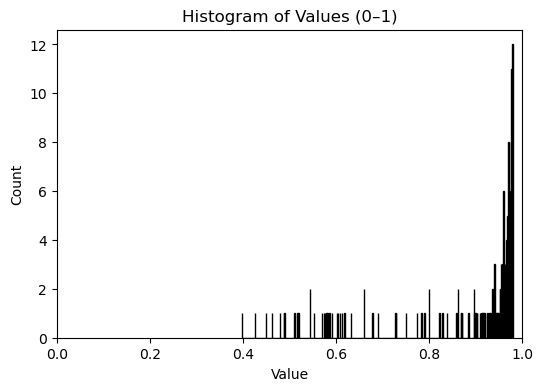

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(df_filtered['alignment_cov'], bins=600, edgecolor="black")
plt.xlim(0, 1)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Histogram of Values (0–1)")
plt.show()


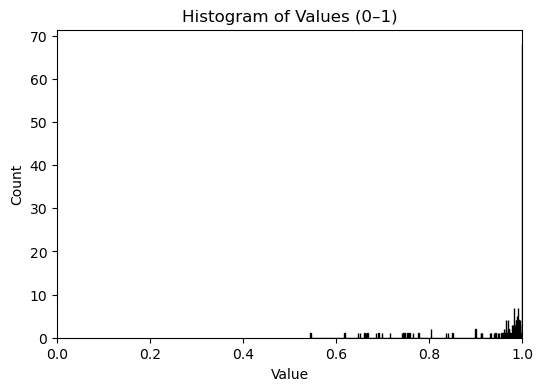

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(df_filtered['alignment_duplicate_cov'], bins=600, edgecolor="black")
plt.xlim(0, 1)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Histogram of Values (0–1)")
plt.show()
